
# Exploratory Data Analysis (EDA) - Student Burnout Prediction
Notebook ini berisi proses eksplorasi data, preprocessing, dan pelatihan model Random Forest untuk dataset `student_burnout.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')



## 1. Data Overview
Memuat dataset dan melihat informasi awalnya.


In [2]:
df = pd.read_csv('dataset/student_burnout.csv')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (2000, 17)


,student_id,grade,gender,sleep_hours,sleep_quality,homework_hours,tests_per_week,extracurricular_hours,num_activities,screen_time_hours,commute_minutes,family_support,friend_support,teacher_support,self_rated_stress,burnout_score,high_burnout
0,1,12,Male,6.3,4,2.1,1,2.4,2,4.8,26.0,2,3,3.0,3,4,1
1,2,10,Female,6.3,4,0.0,2,7.1,1,3.7,43.0,2,5,4.0,4,3,0
2,3,12,Male,8.9,5,3.8,0,1.4,1,6.6,29.0,3,4,3.0,3,3,0
3,4,11,Male,10.4,4,2.5,2,16.4,1,2.3,2.0,4,4,1.0,2,3,0
4,5,9,Female,7.7,4,1.8,1,8.0,1,2.0,13.0,4,5,4.0,1,2,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             2000 non-null   int64  
 1   grade                  2000 non-null   int64  
 2   gender                 2000 non-null   str    
 3   sleep_hours            2000 non-null   float64
 4   sleep_quality          2000 non-null   int64  
 5   homework_hours         2000 non-null   float64
 6   tests_per_week         2000 non-null   int64  
 7   extracurricular_hours  2000 non-null   float64
 8   num_activities         2000 non-null   int64  
 9   screen_time_hours      1956 non-null   float64
 10  commute_minutes        1970 non-null   float64
 11  family_support         2000 non-null   int64  
 12  friend_support         2000 non-null   int64  
 13  teacher_support        1952 non-null   float64
 14  self_rated_stress      2000 non-null   int64  
 15  burnout_score  


## 2. Preprocessing Data & Feature Engineering
Membuat label target `burnout_level` (Low/Medium/High) dari `burnout_score` (1-5).


burnout_level
Medium    825
High      638
Low       537
Name: count, dtype: int64


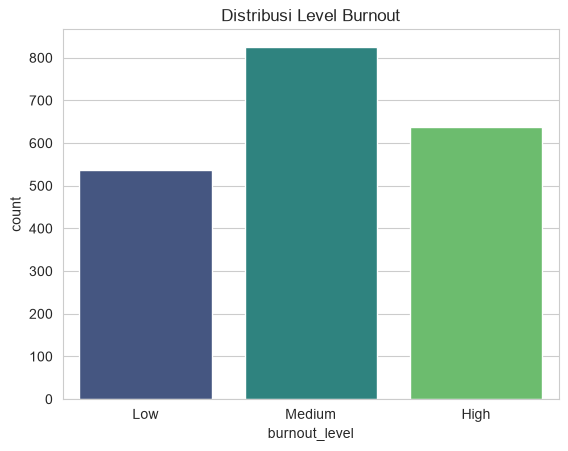

In [4]:
def map_score(score):
    if score <= 2:
        return 'Low'
    elif score == 3:
        return 'Medium'
    else:
        return 'High'

df['burnout_level'] = df['burnout_score'].apply(map_score)

# Melihat distribusi target baru
print(df['burnout_level'].value_counts())
sns.countplot(data=df, x='burnout_level', order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Distribusi Level Burnout')
plt.show()



### Menangani Missing Values dan Kolom Tidak Penting


In [5]:
# Drop kolom yang tidak digunakan sebagai fitur
cols_to_drop = ['student_id', 'burnout_score', 'high_burnout']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Drop missing values
df = df.dropna().drop_duplicates()
print(f"Shape setelah cleaning: {df.shape}")


Shape setelah cleaning: (1878, 15)



## 3. Exploratory Data Analysis (EDA)
Melihat hubungan antara beberapa fitur kunci dengan tingkat burnout.


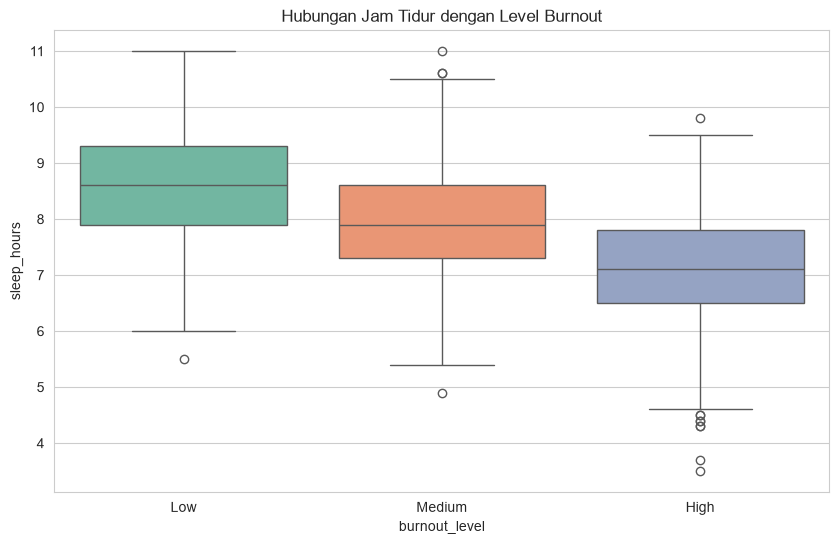

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='burnout_level', y='sleep_hours', order=['Low', 'Medium', 'High'], palette='Set2')
plt.title('Hubungan Jam Tidur dengan Level Burnout')
plt.show()


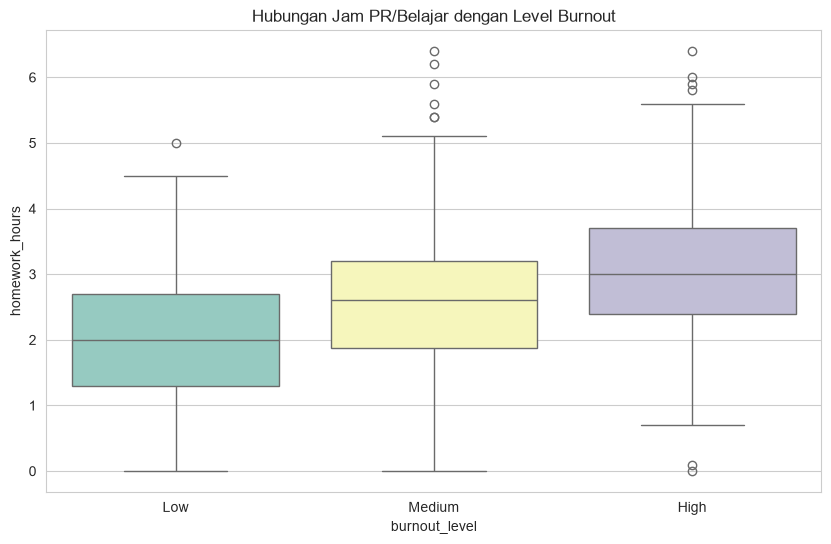

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='burnout_level', y='homework_hours', order=['Low', 'Medium', 'High'], palette='Set3')
plt.title('Hubungan Jam PR/Belajar dengan Level Burnout')
plt.show()


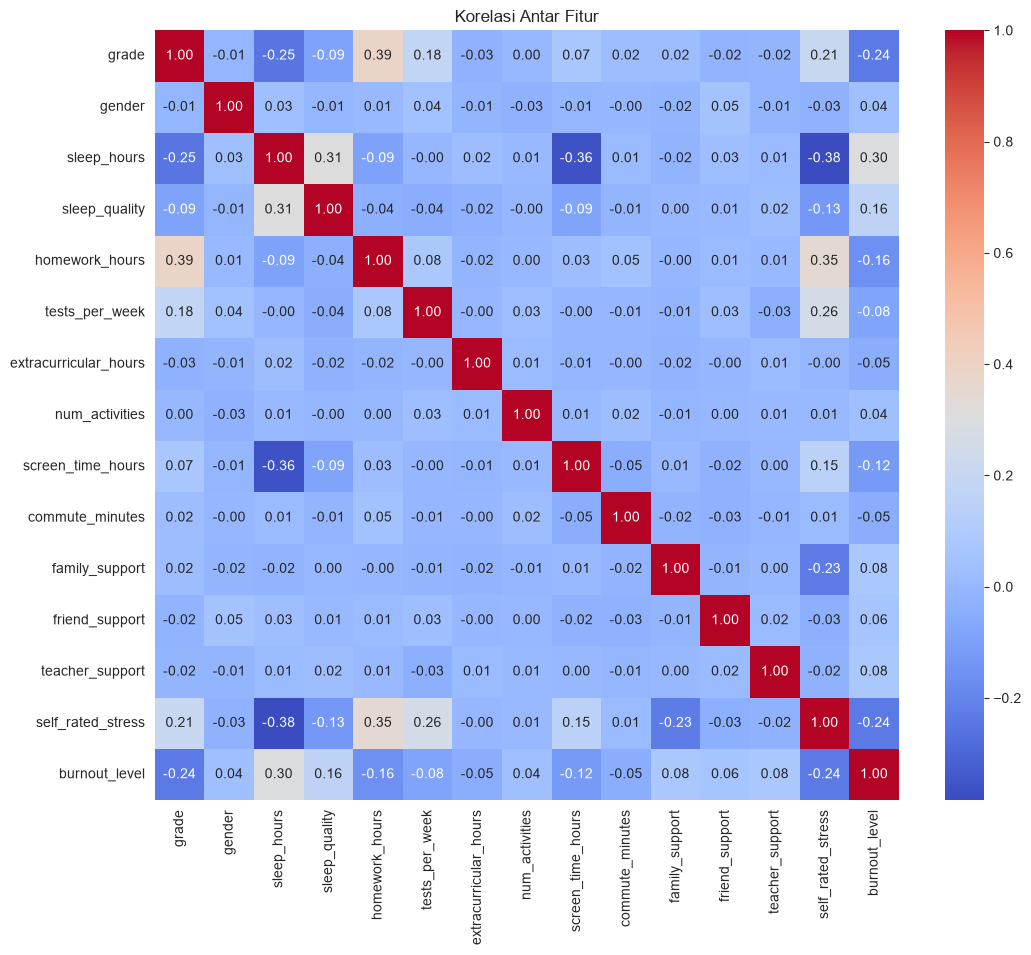

In [8]:
# Encoding categorical data for correlation heatmap
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Antar Fitur')
plt.show()



## 4. Modeling - Random Forest Classifier
Melatih model Random Forest dan mengevaluasi akurasinya.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_encoded.drop('burnout_level', axis=1)
y = df_encoded['burnout_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
rf = RandomForestClassifier(n_estimators=200, min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Prediksi
y_pred = rf.predict(X_test_scaled)

# Hitung Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Random Forest Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))



✅ Random Forest Accuracy: 65.96%

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.61      0.65       119
           1       0.83      0.61      0.70       102
           2       0.57      0.74      0.64       155

    accuracy                           0.66       376
   macro avg       0.70      0.65      0.67       376
weighted avg       0.68      0.66      0.66       376



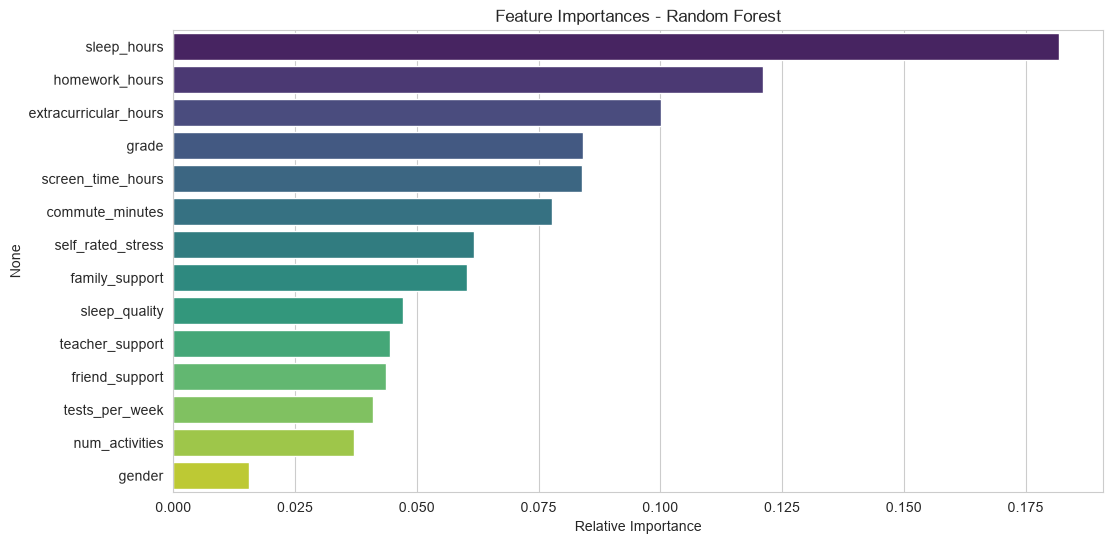

In [10]:
# Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
plt.title('Feature Importances - Random Forest')
plt.xlabel('Relative Importance')
plt.show()
